<div align="center"> 
<img src="alternativeto_icon.png" width="200">

# ***AlternativeTo Software Analysis***
### Comparative Analysis of Software Alternatives Using Data from the AlternativeTo Website

 </div>

 ## 🔍 Project Overview
##### This project focuses on comparing and analyzing software alternatives using data collected from the AlternativeTo website.      
##### It aims to analyze the distribution of software applications across categories, licensing models, supported platforms, languages, and countries  of origin, providing a comprehensive understanding of the software ecosystem.       
##### The project helps developers, companies, researchers, and end users compare software alternatives and make informed decisions when selecting software solutions.







 --- 
 ## 🔄 Project Workflow
![Workflow Diagram](Data_Pipeline.png)

 ---
 ## 🛠️ Technology Stack 


| **Category** | **Technology** |
|:---------|:-----------|
| ***Programming Language*** | *Python* |
| ***Data Collection*** | *Playwright* |  
| ***Data Manipulation*** | *Pandas* , *Numpy* , *pycountry_convert* ,*pyodbc*|
| ***Data Visualization*** | *Matplotlib, Seaborn ,streamlit, Plotly* |
|***Data Storage***	|*SQL Server*|


 ---

### **Project Documentation:-**

https://sites.google.com/view/vector-team-space/home?authuser=0

<div style="color: Orange; text-align: center; padding: 7px; border-radius: 5px; font-weight: bold; font-size: 25px;">Analysis Implementation 
</div>

### **1- Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import pycountry_convert as pc 
import pyodbc 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
BLACK  = "black"
ORANGE = "orange"
GREY = "grey"
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BLACK,      # Background of the plot
    "figure.facecolor": BLACK,    # Background of the entire figure
    "axes.edgecolor": ORANGE,     # Border color
    "grid.color": GREY,           # Grid line color
    "text.color": "white",        # Text color
    "xtick.color": "white",       # X-axis tick color
    "ytick.color": "white",       # Y-axis tick color
    "axes.labelcolor": "white",   # Axis labels
    "axes.titlesize": 16})

### **2- Data Loading**

In [3]:
# Loaded the batches
apps_batch_1 = pd.read_csv(r"C:\Users\EL_Nour\Downloads\GDGC_Project_1\software-substitution-analytics\Data\Scraped_data\apps_batch_1-50.csv")
apps_batch_2 = pd.read_csv(r"C:\Users\EL_Nour\Downloads\GDGC_Project_1\software-substitution-analytics\Data\Scraped_data\apps_batch_51-100.csv")
apps_batch_3 = pd.read_csv(r"C:\Users\EL_Nour\Downloads\GDGC_Project_1\software-substitution-analytics\Data\Scraped_data\apps_batch_101-150.csv")
# merged the batches
merged_apps = pd.concat([apps_batch_1,apps_batch_2,apps_batch_3],ignore_index=True)
# rename to header columns
merged_apps.columns= ['App_name','App_description','Pricing_type','License_type','App_type','Origin_country','Platform','Supported_languages']
# copied merged_apps into variable Apps_dataset for cleaning
Apps_dataset = merged_apps.copy()
Apps_dataset

,App_name,App_description,Pricing_type,License_type,App_type,Origin_country,Platform,Supported_languages
0,Nub,Nub is a TypeScript-first toolkit for Node.js:...,Free,Open Source ( MIT ),"Package Manager, Runtime Environment",NaN,"Mac, Windows, Linux, Homebrew, Nix Package Man...",English
1,OpenKnowledge,OpenKnowledge is a beautiful markdown editor w...,Free,Open Source ( GPL-3.0 ),"Note-taking Tool, Team Collaboration Tool",United States,"Mac, Windows, Linux, Node.JS",English
2,TCP Viewer,"Real-time macOS network tool captures, display...",Pay once,Open Source ( GPL-2.0 ),Network Analyzer,United States,Mac,English
3,Dolfer,Dolfer is a desktop file organizer that automa...,Pay once,Proprietary,System Cleaner,United States,"Windows, Mac, Linux",English
4,TidyBar,TidyBar is a macOS menu-bar app that reclaims ...,Freemium (Pay once),Proprietary,Duplicate File Finder,"Germany, EU",Mac,"English, German"
...,...,...,...,...,...,...,...,...
3737,LINE Camera,LINE Photo Editor.,Free,Proprietary,NaN,Japan,"Android, iPhone, iPad","English, Chinese, French, German, Hindi, Indon..."
3738,Megalodon,A fork of the official Mastodon Android app ad...,Free,Open Source ( GPL-3.0 ),"Mastodon Client, Microblog",International,"Android, Android Tablet, F-Droid","English, Indonesian"
3739,Movylo,Movylo helps you send personal and engaging me...,Freemium (Subscription),Proprietary,"Food Delivery Platform, Food Ordering System Tool",NaN,"Online, iPhone, Google Apps","English, Italian, Spanish"
3740,PhotoShoot.ai,Generate Ecommerce product photography using AI.,Freemium (Subscription),Proprietary,NaN,NaN,Online,English


### **3- Data Understanding**

In [4]:
Apps_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3742 entries, 0 to 3741
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   App_name             3742 non-null   str  
 1   App_description      3742 non-null   str  
 2   Pricing_type         3742 non-null   str  
 3   License_type         3742 non-null   str  
 4   App_type             2754 non-null   str  
 5   Origin_country       2219 non-null   str  
 6   Platform             3742 non-null   str  
 7   Supported_languages  3740 non-null   str  
dtypes: str(8)
memory usage: 1.3 MB


In [5]:
Apps_dataset.shape

(3742, 8)

In [6]:
Apps_dataset.columns

Index(['App_name', 'App_description', 'Pricing_type', 'License_type',
       'App_type', 'Origin_country', 'Platform', 'Supported_languages'],
      dtype='str')

In [7]:
Apps_dataset.describe()

,App_name,App_description,Pricing_type,License_type,App_type,Origin_country,Platform,Supported_languages
count,3742,3742,3742,3742,2754,2219,3742,3740
unique,3708,3711,10,19,816,81,780,540
top,Loupe,"Displays device details exposed for tracking, ...",Free,Proprietary,"AI Chatbot, Large Language Model (LLM) Tool",United States,Online,English
freq,2,2,1726,2494,48,883,758,2943


In [8]:
Apps_dataset.isna().sum()

App_name                  0
App_description           0
Pricing_type              0
License_type              0
App_type                988
Origin_country         1523
Platform                  0
Supported_languages       2
dtype: int64

In [9]:
Apps_dataset.duplicated().sum()

np.int64(31)

<div style="color: Green;  padding: 7px; border-radius: 5px; font-weight: bold; font-size: 25px;"> Data Cleaning </div>

#### 1- Handling Duplicate values

In [10]:
# Check for duplicate values
Apps_dataset[Apps_dataset.duplicated()]

,App_name,App_description,Pricing_type,License_type,App_type,Origin_country,Platform,Supported_languages
25,Loupe,"Displays device details exposed for tracking, ...",Free,Open Source ( MIT ),Privacy Tool,Canada,"iPhone, iPad","English, Arabic, Chinese, French, German, Ital..."
125,Mimik,Auto-capture any browser workflow into a step-...,Free,Open Source ( MIT ),Product Demo Builder,United Kingdom,"Microsoft Edge, Google Chrome, Mozilla Firefox",English
126,Velxio,"Emulate Arduino, ESP32 & Raspberry Pi. in your...",Freemium (Subscription),Open Source ( AGPL-3.0 ),NaN,Uruguay,"Online, Self-Hosted","English, Spanish, Italian, French, German, Jap..."
150,DiscAlt,"Anonymous chat, voice, and video platform usin...",Free,Proprietary,Social Network,United States,"Mac, Windows, Linux, Online, iPhone, iPad",English
275,Radial,"Create powerful macros, trigger them with a ge...",Pay once,Proprietary,Application Launcher,"Denmark, EU",Mac,English
376,Noctalia,"Noctalia is a beautiful, minimal desktop shell...",Free,Open Source ( MIT ),Desktop Environment,NaN,Linux,English
575,GitHub Spark,AI-powered tool for creating and sharing innov...,Subscription,Proprietary,"Website Builder, Web App Development Tool",United States,"Online, Software as a Service (SaaS), GitHub",English
944,Habby,"Transform routines with Habby, an elegant mini...",Free,Proprietary,Habit Tracker,NaN,"Android, iPhone, iPad, Android Tablet","English, Spanish, Dutch, French, Portuguese, G..."
945,Blitzit,Optimize productivity with a simple to-do list...,Pay once or Subscription,Proprietary,"Todo List Manager, Task Management Tool",United Kingdom,"Mac, Windows",English
946,Podcatcher: Podcast App,"Podcatcher offers a free, ad-free podcast expe...",Free,Proprietary,Podcast Player,NaN,iPhone,English


In [11]:
# Remove duplicate Values
Apps_dataset=Apps_dataset.drop_duplicates()
# check that duplicates have been removed
Apps_dataset.duplicated().sum()

np.int64(0)

In [12]:
print("the shape after Remove duplicate Values = ",Apps_dataset.shape)

the shape after Remove duplicate Values =  (3711, 8)


#### 2- Handling Missing values

In [13]:
Apps_dataset['App_type'] = Apps_dataset['App_type'].fillna('Unknown')
Apps_dataset['Origin_country'] = Apps_dataset['Origin_country'].fillna('Unknown')
Apps_dataset['Supported_languages'] = Apps_dataset['Supported_languages'].fillna('Unknown')
# check that Missing values have been Handled
Apps_dataset.isna().sum()

App_name               0
App_description        0
Pricing_type           0
License_type           0
App_type               0
Origin_country         0
Platform               0
Supported_languages    0
dtype: int64

#### 3- cleaning the 'Origin_country' column

In [14]:
Apps_dataset[['Origin_country', 'Region_group']] = Apps_dataset['Origin_country'].str.split(',', expand=True) 
Apps_dataset.drop('Region_group',axis=1,inplace=True)

In [15]:
Apps_dataset['Origin_country']=Apps_dataset['Origin_country'].replace('Tأ¼rkiye', 'Turkiye')

#### 4- Loading the dataset before Extract new columns

In [16]:
Apps_dataset.to_csv("Apps_dataset_clean.csv", index=False, encoding="utf-8-sig")

#### 5- Extract columns from existing columns

In [17]:
Apps_dataset['License_category'] = np.where(Apps_dataset['License_type'].str.contains('Open Source'),'Open Source', 'Proprietary')

In [18]:
Apps_dataset['Num_Languages'] = Apps_dataset['Supported_languages'].str.count(',') + 1

In [19]:
Apps_dataset['Num_Platform'] = Apps_dataset['Platform'].str.count(',') + 1

In [20]:
Apps_dataset['Pricing_categories'] = np.where(Apps_dataset['Pricing_type'].str.contains('Freemium'),'Freemium',
                               np.where(Apps_dataset['Pricing_type'].str.contains('Free'),'Free',
                               np.where(Apps_dataset['Pricing_type'].str.contains('Paid'),'Paid',
                               np.where(Apps_dataset['Pricing_type'].str.contains('Pay once or Subscription'),'Pay once or Subscription',
                               np.where(Apps_dataset['Pricing_type'].str.contains('Subscription'),'Subscription',
                               np.where(Apps_dataset['Pricing_type'].str.contains('Pay once'),'Pay once', 'Unknown' ))))))

In [21]:
Apps_dataset['Desktop'] = Apps_dataset['Platform'].str.contains('Windows|macOS|Mac|Linux|Ubuntu|Debian|Fedora|Chrome OS')
Apps_dataset['Mobile'] = Apps_dataset['Platform'].str.contains('Android|macOS|iPad|iPadOS|Mobile|Debian|Fedora|Telegram|Self-Hosted|SnapChat|visionOS|Kindle Fire|Sailfish OS|Kobo|F-Droid|Jellyfin')
Apps_dataset['Web'] = Apps_dataset['Platform'].str.contains('Web|Browser|Online|Website|Chrome|Firefox|Edge|Safari|Salesforce.com')
Apps_dataset

,App_name,App_description,Pricing_type,License_type,App_type,Origin_country,Platform,Supported_languages,License_category,Num_Languages,Num_Platform,Pricing_categories,Desktop,Mobile,Web
0,Nub,Nub is a TypeScript-first toolkit for Node.js:...,Free,Open Source ( MIT ),"Package Manager, Runtime Environment",Unknown,"Mac, Windows, Linux, Homebrew, Nix Package Man...",English,Open Source,1,8,Free,True,False,False
1,OpenKnowledge,OpenKnowledge is a beautiful markdown editor w...,Free,Open Source ( GPL-3.0 ),"Note-taking Tool, Team Collaboration Tool",United States,"Mac, Windows, Linux, Node.JS",English,Open Source,1,4,Free,True,False,False
2,TCP Viewer,"Real-time macOS network tool captures, display...",Pay once,Open Source ( GPL-2.0 ),Network Analyzer,United States,Mac,English,Open Source,1,1,Pay once,True,False,False
3,Dolfer,Dolfer is a desktop file organizer that automa...,Pay once,Proprietary,System Cleaner,United States,"Windows, Mac, Linux",English,Proprietary,1,3,Pay once,True,False,False
4,TidyBar,TidyBar is a macOS menu-bar app that reclaims ...,Freemium (Pay once),Proprietary,Duplicate File Finder,Germany,Mac,"English, German",Proprietary,2,1,Freemium,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3737,LINE Camera,LINE Photo Editor.,Free,Proprietary,Unknown,Japan,"Android, iPhone, iPad","English, Chinese, French, German, Hindi, Indon...",Proprietary,15,3,Free,False,True,False
3738,Megalodon,A fork of the official Mastodon Android app ad...,Free,Open Source ( GPL-3.0 ),"Mastodon Client, Microblog",International,"Android, Android Tablet, F-Droid","English, Indonesian",Open Source,2,3,Free,False,True,False
3739,Movylo,Movylo helps you send personal and engaging me...,Freemium (Subscription),Proprietary,"Food Delivery Platform, Food Ordering System Tool",Unknown,"Online, iPhone, Google Apps","English, Italian, Spanish",Proprietary,3,3,Freemium,False,False,True
3740,PhotoShoot.ai,Generate Ecommerce product photography using AI.,Freemium (Subscription),Proprietary,Unknown,Unknown,Online,English,Proprietary,1,1,Freemium,False,False,True


In [22]:
# convert Origin_country to country code & country code to contitent code 
def convert(row):
    try:
        country_code = pc.country_name_to_country_alpha2(
        row.Origin_country,cn_name_format="default")
        contitent_code = pc.country_alpha2_to_continent_code(country_code)
        return contitent_code
    except:
        return "Unknown"
# creat a new column with continents code
Apps_dataset['Contitent_name'] = Apps_dataset.apply(convert,axis=1)
Apps_dataset

,App_name,App_description,Pricing_type,License_type,App_type,Origin_country,Platform,Supported_languages,License_category,Num_Languages,Num_Platform,Pricing_categories,Desktop,Mobile,Web,Contitent_name
0,Nub,Nub is a TypeScript-first toolkit for Node.js:...,Free,Open Source ( MIT ),"Package Manager, Runtime Environment",Unknown,"Mac, Windows, Linux, Homebrew, Nix Package Man...",English,Open Source,1,8,Free,True,False,False,Unknown
1,OpenKnowledge,OpenKnowledge is a beautiful markdown editor w...,Free,Open Source ( GPL-3.0 ),"Note-taking Tool, Team Collaboration Tool",United States,"Mac, Windows, Linux, Node.JS",English,Open Source,1,4,Free,True,False,False,NA
2,TCP Viewer,"Real-time macOS network tool captures, display...",Pay once,Open Source ( GPL-2.0 ),Network Analyzer,United States,Mac,English,Open Source,1,1,Pay once,True,False,False,NA
3,Dolfer,Dolfer is a desktop file organizer that automa...,Pay once,Proprietary,System Cleaner,United States,"Windows, Mac, Linux",English,Proprietary,1,3,Pay once,True,False,False,NA
4,TidyBar,TidyBar is a macOS menu-bar app that reclaims ...,Freemium (Pay once),Proprietary,Duplicate File Finder,Germany,Mac,"English, German",Proprietary,2,1,Freemium,True,False,False,EU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3737,LINE Camera,LINE Photo Editor.,Free,Proprietary,Unknown,Japan,"Android, iPhone, iPad","English, Chinese, French, German, Hindi, Indon...",Proprietary,15,3,Free,False,True,False,AS
3738,Megalodon,A fork of the official Mastodon Android app ad...,Free,Open Source ( GPL-3.0 ),"Mastodon Client, Microblog",International,"Android, Android Tablet, F-Droid","English, Indonesian",Open Source,2,3,Free,False,True,False,Unknown
3739,Movylo,Movylo helps you send personal and engaging me...,Freemium (Subscription),Proprietary,"Food Delivery Platform, Food Ordering System Tool",Unknown,"Online, iPhone, Google Apps","English, Italian, Spanish",Proprietary,3,3,Freemium,False,False,True,Unknown
3740,PhotoShoot.ai,Generate Ecommerce product photography using AI.,Freemium (Subscription),Proprietary,Unknown,Unknown,Online,English,Proprietary,1,1,Freemium,False,False,True,Unknown


In [23]:
Apps_dataset["Contitent_name"].unique()

<ArrowStringArray>
['Unknown', 'NA', 'EU', 'AS', 'AF', 'OC', 'SA']
Length: 7, dtype: str

In [24]:
# Map contitent code to Contitent_name
conti_names = {'AF':'Africa','AS':'Asia','EU':'Europe','NA':'North America','OC':'Oceania','SA':'South America','Unknown':'Unknown'}
Apps_dataset['Contitent_name'] = Apps_dataset['Contitent_name'].map(conti_names)
Apps_dataset

,App_name,App_description,Pricing_type,License_type,App_type,Origin_country,Platform,Supported_languages,License_category,Num_Languages,Num_Platform,Pricing_categories,Desktop,Mobile,Web,Contitent_name
0,Nub,Nub is a TypeScript-first toolkit for Node.js:...,Free,Open Source ( MIT ),"Package Manager, Runtime Environment",Unknown,"Mac, Windows, Linux, Homebrew, Nix Package Man...",English,Open Source,1,8,Free,True,False,False,Unknown
1,OpenKnowledge,OpenKnowledge is a beautiful markdown editor w...,Free,Open Source ( GPL-3.0 ),"Note-taking Tool, Team Collaboration Tool",United States,"Mac, Windows, Linux, Node.JS",English,Open Source,1,4,Free,True,False,False,North America
2,TCP Viewer,"Real-time macOS network tool captures, display...",Pay once,Open Source ( GPL-2.0 ),Network Analyzer,United States,Mac,English,Open Source,1,1,Pay once,True,False,False,North America
3,Dolfer,Dolfer is a desktop file organizer that automa...,Pay once,Proprietary,System Cleaner,United States,"Windows, Mac, Linux",English,Proprietary,1,3,Pay once,True,False,False,North America
4,TidyBar,TidyBar is a macOS menu-bar app that reclaims ...,Freemium (Pay once),Proprietary,Duplicate File Finder,Germany,Mac,"English, German",Proprietary,2,1,Freemium,True,False,False,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3737,LINE Camera,LINE Photo Editor.,Free,Proprietary,Unknown,Japan,"Android, iPhone, iPad","English, Chinese, French, German, Hindi, Indon...",Proprietary,15,3,Free,False,True,False,Asia
3738,Megalodon,A fork of the official Mastodon Android app ad...,Free,Open Source ( GPL-3.0 ),"Mastodon Client, Microblog",International,"Android, Android Tablet, F-Droid","English, Indonesian",Open Source,2,3,Free,False,True,False,Unknown
3739,Movylo,Movylo helps you send personal and engaging me...,Freemium (Subscription),Proprietary,"Food Delivery Platform, Food Ordering System Tool",Unknown,"Online, iPhone, Google Apps","English, Italian, Spanish",Proprietary,3,3,Freemium,False,False,True,Unknown
3740,PhotoShoot.ai,Generate Ecommerce product photography using AI.,Freemium (Subscription),Proprietary,Unknown,Unknown,Online,English,Proprietary,1,1,Freemium,False,False,True,Unknown


#### 6- Strip whitespace

In [25]:
Apps_dataset['App_name']= Apps_dataset['App_name'].str.strip()
Apps_dataset['App_description']=Apps_dataset['App_description'].str.strip()
Apps_dataset['Pricing_type']=Apps_dataset['Pricing_type'].str.strip()
Apps_dataset['License_type']=Apps_dataset['License_type'].str.strip()
Apps_dataset['App_type']=Apps_dataset['App_type'].str.strip()
Apps_dataset['Origin_country']=Apps_dataset['Origin_country'].str.strip()
Apps_dataset['Platform']=Apps_dataset['Platform'].str.strip()
Apps_dataset['Supported_languages']=Apps_dataset['Supported_languages'].str.strip()
Apps_dataset['Contitent_name']=Apps_dataset['Contitent_name'].str.strip()
Apps_dataset['License_category']=Apps_dataset['License_category'].str.strip()
Apps_dataset['Pricing_categories']=Apps_dataset['Pricing_categories'].str.strip()

In [26]:
Apps_dataset.shape

(3711, 16)

#### 7- Loading the dataset **after** Extract new columns

In [206]:
Apps_dataset.to_csv("Apps_dataset.csv", index=False,encoding="utf-8-sig")

## connect SQL server to python 

In [27]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=DESKTOP-V8DEK6I\SQLEXPRESS;"
    "DATABASE=Apps_Dataset;"
    "Trusted_Connection=yes;")
print(conn)

## Load Data in python 

In [28]:
Query = "select * from Apps_Data"
Apps_dataset = pd.read_sql_query(Query, conn)
Apps_dataset.shape 

C:\Users\EL_Nour\AppData\Local\Temp\ipykernel_3828\965152653.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Apps_dataset = pd.read_sql_query(Query, conn)


(3711, 16)

In [29]:
License_cross_Pricing= pd.crosstab(Apps_dataset["Pricing_categories"],Apps_dataset["License_category"])
License_cross_Pricing

License_category,Open Source,Proprietary
Pricing_categories,,
Free,1040,718
Freemium,138,995
Paid,2,77
Pay once,9,279
Pay once or Subscription,1,62
Subscription,17,373


<div style="color: Green;  padding: 7px; border-radius: 5px; font-weight: bold; font-size: 25px;"> Exploratory Data Analysis </div>

### **Dataset Overview [Distribution_Apps]**

In [30]:
Total_num_apps = Apps_dataset['App_name'].count()
print("Total_num_apps:" ,Total_num_apps)

Total_num_apps: 3711


#### 1- Num of apps by Pricing_categories

In [31]:
Apps_dataset["Pricing_categories"].value_counts()

Pricing_categories
Free                        1758
Freemium                    1133
Subscription                 390
Pay once                     288
Paid                          79
Pay once or Subscription      63
Name: count, dtype: int64

#### 2- Num of apps by License_category

In [32]:
Apps_dataset["License_category"].value_counts()

License_category
Proprietary    2504
Open Source    1207
Name: count, dtype: int64

#### 3- Num of apps by Contitent_name

In [33]:
Apps_dataset[(Apps_dataset["Contitent_name"] != "Unknown")]['Contitent_name'].value_counts()

Contitent_name
North America    931
Europe           761
Asia             312
Oceania           42
South America     28
Africa            15
Name: count, dtype: int64

#### 4- Most Common Application Types

In [34]:
ignore_Unknown = Apps_dataset[(Apps_dataset['App_type'] != 'Unknown')] 
split_types = ignore_Unknown['App_type'].str.split(', ')
total_type_counts = split_types.explode().value_counts().head(10) 
total_type_counts 

App_type
AI Chatbot                         127
Note-taking Tool                    89
Todo List Manager                   72
Large Language Model (LLM) Tool     70
AI Writing Tool                     70
AI Image Generator                  68
Task Management Tool                64
Audio Transcription Tool            62
Audio Player                        52
Screen Recorder                     50
Name: count, dtype: int64

#### 5- Number of Applications by Platform

In [35]:
print("num_Desktop_app =" ,(Apps_dataset["Desktop"] == "True").sum())
print("num_Mobile_app =" ,(Apps_dataset["Mobile"] == "True").sum())
print("num_Web_app =" ,(Apps_dataset["Web"] == "True").sum())

num_Desktop_app = 1399
num_Mobile_app = 1351
num_Web_app = 1629


#### 6- Top(3) Countries per Continent by Num_Apps

In [36]:
Apps_dataset = Apps_dataset[Apps_dataset["Contitent_name"] != "Unknown"]
topCountries = Apps_dataset.groupby(['Contitent_name', "Origin_country"]).size().reset_index(name="App_Count")
topCountries = topCountries.sort_values( ['Contitent_name', 'App_Count'],ascending=[True, False])
top3 = topCountries.groupby("Contitent_name").head(3)
top3

,Contitent_name,Origin_country,App_Count
1,Africa,Egypt,5
6,Africa,South Africa,3
0,Africa,Algeria,2
12,Asia,India,97
9,Asia,China,74
17,Asia,Japan,28
63,Europe,United Kingdom,153
41,Europe,Germany,152
40,Europe,France,75
68,North America,United States,876


#### 7- Num of apps by Origin_country

In [37]:
Apps_dataset[(Apps_dataset["Origin_country"] != "Unknown")]['Origin_country'].value_counts().head(10)

Origin_country
United States     876
United Kingdom    153
Germany           152
India              97
France             75
China              74
Canada             52
Sweden             41
Australia          34
Italy              32
Name: count, dtype: int64

### **Relationship Analysis**

#### 1- Does License Category affect Pricing Category?

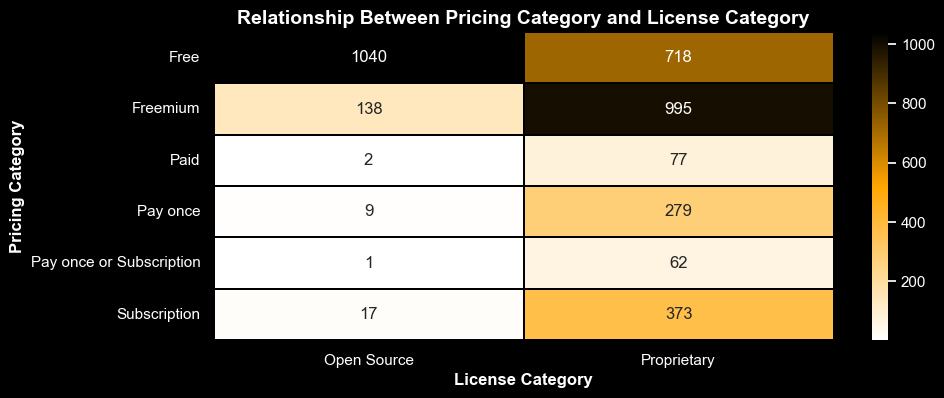

In [38]:

# Heatmap size
plt.figure(figsize=(10, 4))
# Heatmap color
cmap_orange = LinearSegmentedColormap.from_list("BlackOrange",["white","orange", "black"])
# Heatmap
sns.heatmap(License_cross_Pricing,annot=True,fmt="d",cmap=cmap_orange,linewidths=0.1,linecolor="black")
# title and labels  Heatmap
plt.title("Relationship Between Pricing Category and License Category",color= "white",fontweight="bold",fontsize=14)
plt.xlabel("License Category",fontweight="bold")
plt.ylabel("Pricing Category",fontweight="bold")
plt.show()            

#### **`Business Insight`**
##### Free applications are more likely to be open-source, whereas commercial pricing Category (Freemium, Paid, Pay Once, and Subscription) are  proprietary. This indicates a strong Relationship between software monetization strategy and licensing Category.

#### 2- Does Platform affect Pricing Category?

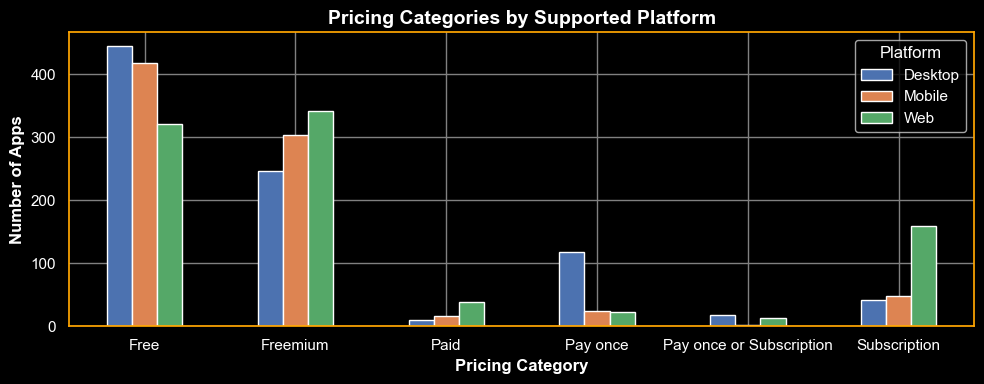

In [37]:
Desktop_cross_Pricing= pd.crosstab(Apps_dataset["Pricing_categories"],Apps_dataset["Desktop"])
Mobile_cross_Pricing= pd.crosstab(Apps_dataset["Pricing_categories"],Apps_dataset["Mobile"])
Web_cross_Pricing= pd.crosstab(Apps_dataset["Pricing_categories"],Apps_dataset["Web"])
Platform_plot = pd.DataFrame({"Desktop": Desktop_cross_Pricing['True'],"Mobile": Mobile_cross_Pricing['True'],"Web": Web_cross_Pricing['True']})

Platform_plot.plot(kind="bar", figsize=(10,4))

plt.title("Pricing Categories by Supported Platform",color= "white",fontweight="bold",fontsize=14)
plt.xlabel("Pricing Category",fontweight="bold")
plt.ylabel("Number of Apps",fontweight="bold")
plt.xticks(rotation=360)
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

#### **`Business Insight`**
##### Web platforms show higher adoption of Subscription and Freemium models, whereas Desktop platforms favor Pay Once pricing. Mobile applications are predominantly Free or Freemium, indicating that pricing strategies vary depending on the platform.

#### 3- Does the number of supported languages affect the pricing category?

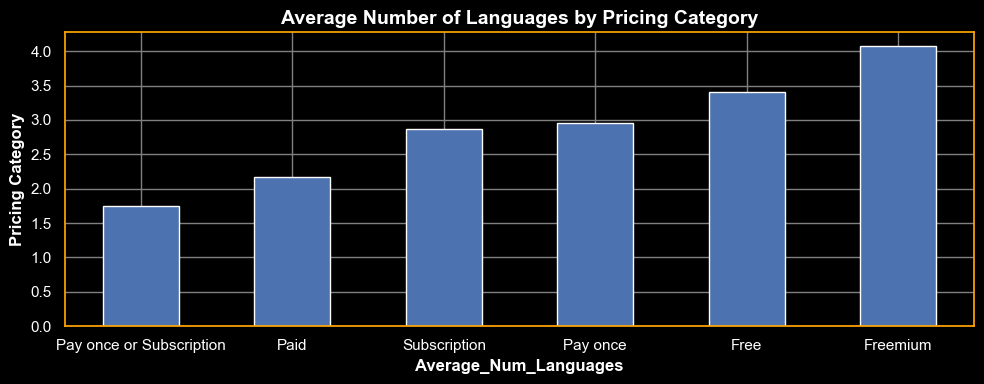

In [38]:
Apps_dataset["Num_Languages"].dtype
Apps_dataset["Num_Languages"] = pd.to_numeric(Apps_dataset["Num_Languages"])
AVG_Languages= Apps_dataset.groupby("Pricing_categories")["Num_Languages"].mean().sort_values()
AVG_Languages.plot(kind="bar", figsize=(10,4))


plt.title('Average Number of Languages by Pricing Category', color= "white",fontweight="bold",fontsize=14)
plt.ylabel('Pricing Category', color='white',fontweight="bold")
plt.xlabel('Average_Num_Languages', color='white',fontweight="bold")
plt.xticks(rotation=360, color='white')
plt.yticks(color='white')
plt.tight_layout()

plt.show()

#### **`Business Insight`**
##### Compared to Free apps, Freemium apps tend to offer broader multilingual support, reflecting a stronger focus on expanding their global user base. Meanwhile, Free apps provide broader language support than Paid apps, suggesting greater accessibility to international markets.

### **Business analysis**

#### 🌍 Geographical Insights

##### 1- Top(3) App Types Developed in Each Continent

In [39]:
#create a copy of dataset after ignore to Unknown values
split_types = ignore_Unknown.copy()
split_types['App_type'] = split_types['App_type'].str.split(', ')
# Convert each app_type into its own row
split_types = split_types.explode("App_type")
# Count the num_apps for each app type in every continent
continent_type_counts = (split_types.groupby(["Contitent_name", "App_type"]).size().reset_index(name="App_Count"))
# Select the top 3 most common app types for each continent
top3_per_continent = (continent_type_counts.sort_values(["Contitent_name", "App_Count"],ascending=[True, False]).groupby("Contitent_name").head(3))
top3_per_continent = top3_per_continent[top3_per_continent["Contitent_name"] != "Unknown"]
top3_per_continent

,Contitent_name,App_type,App_Count
0,Africa,AI Chatbot,3
3,Africa,Audio Player,2
1,Africa,AI Image Generator,1
13,Asia,AI Chatbot,19
103,Asia,Large Language Model (LLM) Tool,15
31,Asia,Application Launcher,10
445,Europe,Todo List Manager,18
207,Europe,AI Chatbot,17
369,Europe,Note-taking Tool,16
493,North America,AI Chatbot,51


#### **`Business Insight`**
##### AI-related applications (AI Chatbots, LLM Tools, AI Writing Tools, AI Image Generators, and AI Coding Assistants) appear among the top-developed categories in most continents. However, North America and Asia exhibit the strongest concentration of AI-focused development, while Europe and South America show greater interest in productivity applications such as task management and note-taking.

##### 3- Supported Platforms Across Continents

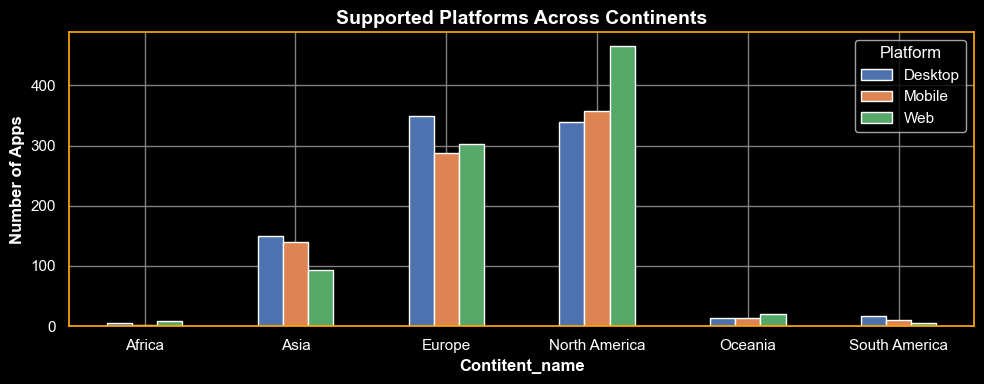

In [40]:
continent_platforms = (Apps_dataset.groupby("Contitent_name").agg(
        Desktop=("Desktop", lambda x: (x == "True").sum()),
        Mobile=("Mobile", lambda x: (x == "True").sum()),
        Web=("Web", lambda x: (x == "True").sum())).reset_index())
continent_platforms = continent_platforms[continent_platforms["Contitent_name"] != "Unknown"]
Platform_plot = continent_platforms.set_index("Contitent_name")
#  using barGroup
Platform_plot.plot(kind="bar", figsize=(10,4))
plt.title("Supported Platforms Across Continents",fontweight="bold",fontsize=14)
plt.xlabel("Contitent_name", fontweight="bold")
plt.ylabel("Number of Apps", fontweight="bold")
plt.xticks(rotation=0)
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

#### **`Business Insight`**
##### Web and Desktop platforms dominate app development across most continents. Web development is particularly strong in North America, while Desktop applications remain highly popular in Europe and Asia. Mobile support is significant but generally ranks behind the leading platform in most regions represented in the dataset.

#### Platform analysis 

##### 1- Operating System Comparison

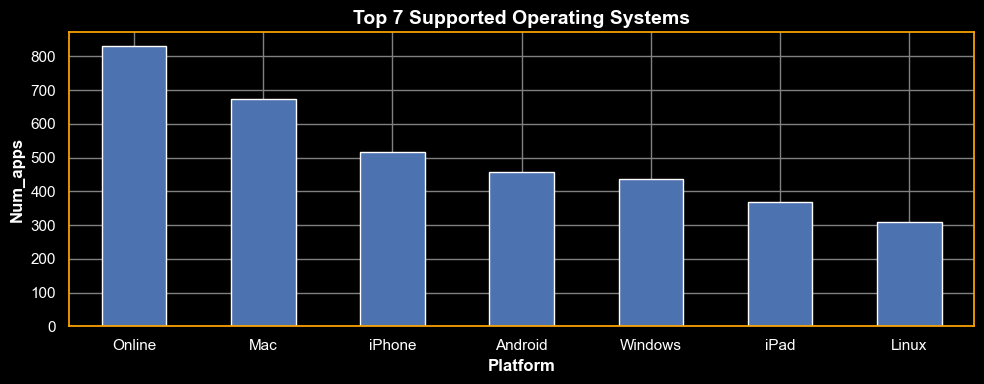

In [41]:
ignore_Unknown = Apps_dataset[(Apps_dataset['Platform'] != 'Unknown')] 
split_types = ignore_Unknown['Platform'].str.split(', ')
Platform_counts = split_types.explode().value_counts().head(7) 

Platform_counts.plot(kind="bar", figsize=(10,4))
plt.title('Top 7 Supported Operating Systems', color= "white",fontweight="bold",fontsize=14)
plt.ylabel('Num_apps', color='white',fontweight="bold")
plt.xlabel('Platform', color='white',fontweight="bold")
plt.xticks(rotation=360, color='white')
plt.yticks(color='white')
plt.tight_layout()

plt.show()

#### **`Business Insight`**
##### Mac leads in application support among desktop operating systems, followed by Windows, while Linux has the fewest supported applications. This indicates that developers primarily focus on Mac and Windows, reflecting higher market demand and broader user adoption, whereas Linux remains a lower development priority

##### 2- Pricing Categories of Mac Applications

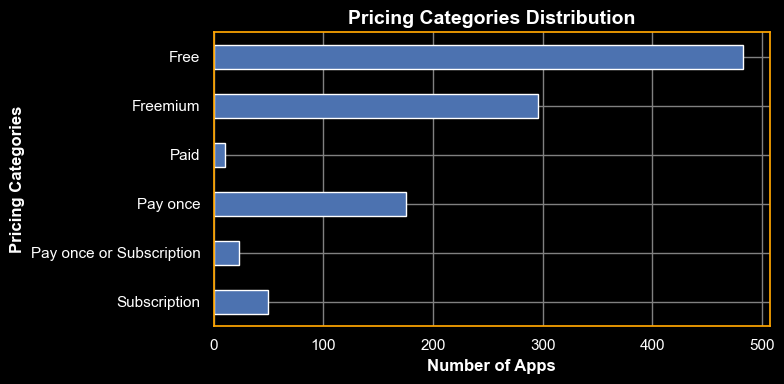

In [71]:
Apps_dataset['Platform'] = Apps_dataset['Platform'].str.split(', ')
Platform_counts = Apps_dataset.explode('Platform')
Mac_apps = Platform_counts[Platform_counts['Platform'] == 'Mac']
pricing_counts =Mac_apps.groupby("Pricing_categories").size().reset_index(name="app_counts")

pricing_counts.plot(kind="barh",x="app_counts",y="Pricing_categories",figsize=(8,4),legend=False) 

plt.title('Pricing Categories Distribution', color= "white",fontweight="bold",fontsize=14)
plt.xlabel('Number of Apps', color='white',fontweight="bold")
plt.ylabel('Pricing Categories', color='white',fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### **`Business Insight`**
##### The Mac ecosystem is primarily driven by Free and Freemium applications. This suggests that developers prefer maximizing user adoption and visibility rather than relying on upfront purchases or subscription-based monetization.

##### 3-Pricing Categories of Linux Applications

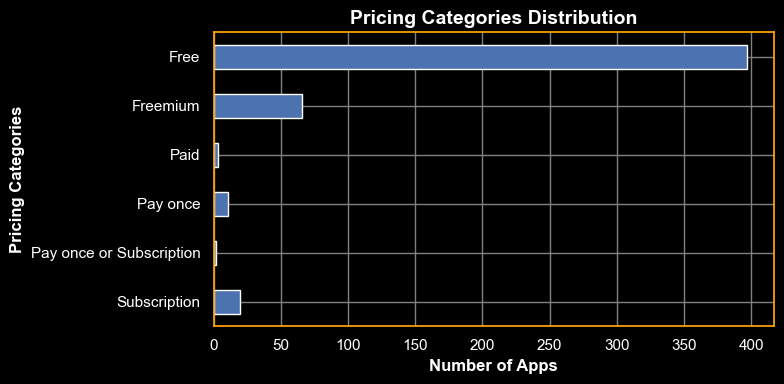

In [100]:
Apps_dataset['Platform'] = Apps_dataset['Platform'].str.split(', ')
Platform_counts = Apps_dataset.explode('Platform')
Linux_apps = Platform_counts[Platform_counts['Platform'] == 'Linux']
pricing_counts =Linux_apps.groupby("Pricing_categories").size().reset_index(name="app_counts")

pricing_counts.plot(kind="barh",x="Pricing_categories",y="app_counts",figsize=(8,4),legend=False) 
plt.title('Pricing Categories Distribution', color= "white",fontweight="bold",fontsize=14)
plt.xlabel('Number of Apps', color='white',fontweight="bold")
plt.ylabel('Pricing Categories', color='white',fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### **`Business Insight`**
##### The Linux ecosystem is heavily centered around free applications. Developers appear to focus on accessibility and community adoption, while paid and subscription-based monetization remains relatively uncommon compared to free distribution.

##### 4- Distribution of Supported Languages Across Applications

In [188]:
Num_Languages=Apps_dataset["Num_Languages"].value_counts().sort_index().head(10)
Num_Languages

Num_Languages
1     2927
2      207
3       58
4       43
5       40
6       37
7       44
8       45
9       29
10      36
Name: count, dtype: int64

#### **`Business Insight`**
##### The analysis of supported languages shows a highly imbalanced distribution. The vast majority of applications (2927 apps) support only one language, indicating a strong focus on localized or single-market deployment. The number of applications drops sharply for apps supporting two languages (207 apps), and continues to decline significantly as the number of supported languages increases. This suggests that multilingual support is not a common feature among most applications, with only a small fraction targeting a global audience.ر

### **4- Results & Insights** 

### 1- Geographic Insights

#### Development is concentrated in **North America (931)** and **Europe (761)**, led by the **US (876)**, **UK (153)**, and **Germany (152)**. AI-related tools rank highest in North America and Asia, while Europe and South America lean toward productivity apps. Web and Desktop dominate platform support in almost every region.

### 2- Pricing Categories Insights

#### - The pricing distribution indicates a strong preference for low-entry-barrier monetization strategies. Free and Freemium models account for the majority of applications, whereas direct paid models remain relatively uncommon.

#### - Free applications are more likely to be open-source, whereas commercial pricing Category (Freemium, Paid, Pay Once, and Subscription) are proprietary. This indicates a strong Relationship between software monetization strategy and licensing Category.

#### - Web platforms show higher adoption of Subscription and Freemium models, whereas Desktop platforms favor Pay Once pricing. Mobile applications are predominantly Free or Freemium, indicating that pricing strategies vary depending on the platform.

#### - Compared to Free apps, Freemium apps tend to offer broader multilingual support, reflecting a stronger focus on expanding their global user base. Meanwhile, Free apps provide broader language support than Paid apps, suggesting greater accessibility to international markets.

#### - The Mac ecosystem is primarily driven by Free and Freemium applications. This suggests that developers prefer maximizing user adoption and visibility rather than relying on upfront purchases or subscription-based monetization.

#### - The Linux ecosystem is heavily centered around free applications. Developers appear to focus on accessibility and community adoption, while paid and subscription-based monetization remains relatively uncommon compared to free distribution.

### 3- Platform Insights

#### **Web (1,629)** slightly leads **Desktop (1,399)** and **Mobile (1,351)**. Among desktop OS, **Mac** leads, followed by **Windows**, then **Linux**. Both Mac and Linux ecosystems favor Free/Freemium apps, showing an adoption-first approach over commercial monetization.

### 4- Language Support Insights

#### **2,927 apps** support only one language, with sharp drop-off beyond that — most products target a single market. **Freemium** apps tend to support more languages than **Free** apps, which in turn support more than **Paid** apps.

### 5- Application Types Insights

#### **AI Chatbot (127 apps)** is the single most common app type overall, followed by **Note-taking Tool (89)**, **Todo List Manager (72)**, **LLM Tool (70)**, and **AI Writing Tool (70)** — showing AI-driven categories already lead the general market, before even breaking it down by region.

### **6- Recommendations**

##### 1- Evaluate market competition before selecting an application category; highly competitive categories require clear differentiation.
##### 2- Align the pricing model with the target platform (Web/Mobile → Free or Freemium, Desktop → Pay Once).
##### 3- Choose the licensing model based on business goals (Open Source for wider adoption, Proprietary for direct revenue).
##### 4- Support multiple languages to increase market reach and gain a competitive advantage.
##### 5- Consider regional market differences when targeting users, as application preferences vary across geographic regions.

### **7- References**

#### Strip whitespace
https://www.geeksforgeeks.org/pandas/pandas-strip-whitespace-from-entire-dataframe/

####  Extract columns from existing column
https://youtu.be/oTf-C-jvU_k?si=qvMj_j2chLiZZITh
#### convert Origin_country to Contitent_name
https://www.youtube.com/watch?v=VMIRK36d-EY

#### count the num.Supported_languages
using count() +1 ---> لان عدد الفواصل اقل من عدد اللغات بواحد       
https://pandas.pydata.org/docs/reference/api/pandas.Series.str.count

#### connect SQL server to python & Load Data in python
https://youtu.be/g69lFxZdcVQ?si=R5Zp1cLfM97PsJc2

https://youtu.be/Y1OFbez9qK0?si=pZt9kNevV24WaEmj

https://youtu.be/0E4AuCqgN90?si=i8rcLuWm6JH5fl7k 